# Validating Quantum Dynamics: The Transverse-Field Ising Model
---

This notebook provides an end-to-end validation of the Fourier-coefficient PAC learning framework applied to the Transverse-Field Ising Model (TFIM). We track the observable trajectory $\langle O(t) \rangle$ of a held-out test state across continuous time $t \in [0, 3]$, comparing three signals:

1. **Exact Evolution** (Continuous Black Line): $U(t) = \exp(-iHt)$ computed via dense matrix exponentiation.
2. **Trotterized Ground Truth** (Blue Dots): The discretized dynamics natively generated by the $A(U)$ extraction circuit.
3. **PAC-Learned Prediction** (Red Crosses): The dynamics predicted by our ML framework, trained strictly on Trotterized labels.

If the theoretical framework holds, the PAC-learned predictions will perfectly track the Trotterized simulation, demonstrating zero generalization gap, while both track the exact physics modulo standard Trotter step-error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from quantum_learning_dynamics import Experiment
from quantum_learning_dynamics.hamiltonians.tfim import TFIM, InhomogeneousTFIM
from quantum_learning_dynamics.observables.library import StaggeredMagnetization, LocalMagnetization, TwoPointZZCorrelator

# Professional plotting styles
plt.rcParams.update({
    'figure.dpi': 120, 
    'axes.grid': True, 
    'grid.alpha': 0.3, 
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

SEED = 42
T_DENSE = np.linspace(0.0, 3.0, 100)        # Smooth curve for exact physics
T_VALS  = np.linspace(0.01, 3.0, 13)        # Discrete points for learning framework

## Part 1: Homogeneous Regime ($d = 1$)
---
**Hamiltonian:** $H(x, \alpha) = \sum_{(i,j) \in x} Z_i Z_j + \alpha \sum_i X_i$ 

In the homogeneous regime, the system is governed by a single global field strength $\alpha$. Because $d=1$, the extraction circuit routes all parameter shifts into a single shared frequency register. The learning task is heavily overdetermined, allowing us to use standard $L_1$ Lasso Regression (`hadamard_lasso`).

In [2]:
NUM_QUBITS_1 = 3
R_STEPS_1    = 3

# 1. Initialize Physics and Observable
model_1 = TFIM(num_qubits=NUM_QUBITS_1, edge_prob=0.5, alpha_range=(0.6, 1.4))
obs_1   = LocalMagnetization(num_qubits=NUM_QUBITS_1)

# 2. Fix the state configuration and ground truth
alpha_star_1 = np.array([1.0])
rng = np.random.default_rng(SEED)
X_train_1 = [model_1.sample_x(rng) for _ in range(30)]
test_state_1 = [(0, 1), (1, 2)]  # A held-out 3-qubit chain graph

print(f"Training set size: {len(X_train_1)} graphs")
print(f"Held-out Test State: {test_state_1}")

Training set size: 30 graphs
Held-out Test State: [(0, 1), (1, 2)]


In [3]:
# Compute dense exact trajectory via matrix exponentiation
O_mat_1 = obs_1.to_sparse_pauli_op().to_matrix()
exact_traj_1 = np.empty(len(T_DENSE))

for i, t in enumerate(T_DENSE):
    if t == 0.0:
        psi = np.zeros(2**NUM_QUBITS_1, dtype=complex); psi[0] = 1.0
    else:
        U = model_1.exact_unitary(test_state_1, alpha_star_1, float(t))
        psi = U[:, 0]
    exact_traj_1[i] = float(np.real(np.conj(psi) @ O_mat_1 @ psi))

In [4]:
# Compute PAC-Learned and Trotter dynamics across time
trotter_pts_1 = np.empty(len(T_VALS))
pac_pts_1     = np.empty(len(T_VALS))

for j, tau in enumerate(T_VALS):
    t_0 = time.time()
    exp = Experiment(
        model=model_1, observable=obs_1, method='hadamard_lasso',
        tau=float(tau), r_steps=R_STEPS_1,
        trotter_order=2,
        lasso_alpha=1e-5, seed=SEED
    )
    
    # Generate Training Data and Fit
    y_train = exp.compute_trotter_labels(X_train_1, alpha_star_1, float(tau), R_STEPS_1)
    B_train = exp._extract_features(X_train_1)
    exp.learner.fit(B_train, y_train)

    # Predict on Held-Out Test State
    B_test = exp._extract_features([test_state_1])
    pac_pts_1[j]     = float(exp.learner.predict(B_test)[0])
    trotter_pts_1[j] = float(exp.compute_trotter_labels([test_state_1], alpha_star_1, float(tau), R_STEPS_1)[0])

    # Calculate Exact value at this specific tau
    U = model_1.exact_unitary(test_state_1, alpha_star_1, float(tau))
    psi = U[:, 0]
    exact_val = float(np.real(np.conj(psi) @ O_mat_1 @ psi))
    
    print(f"t={tau:5.2f} | Exact: {exact_val:+.4f} | Trotter: {trotter_pts_1[j]:+.4f} | PAC: {pac_pts_1[j]:+.4f} | Time: {time.time() - t_0:.2f}s")

t= 0.01 | Exact: +0.9998 | Trotter: +0.9998 | PAC: +0.9998 | Time: 1.65s
t= 0.26 | Exact: +0.8715 | Trotter: +0.8712 | PAC: +0.8702 | Time: 0.68s
t= 0.51 | Exact: +0.5649 | Trotter: +0.5611 | PAC: +0.5638 | Time: 0.79s
t= 0.76 | Exact: +0.2164 | Trotter: +0.2028 | PAC: +0.2047 | Time: 0.89s
t= 1.01 | Exact: -0.0378 | Trotter: -0.0627 | PAC: -0.0615 | Time: 0.88s
t= 1.26 | Exact: -0.1315 | Trotter: -0.1563 | PAC: -0.1590 | Time: 0.84s
t= 1.51 | Exact: -0.0912 | Trotter: -0.0942 | PAC: -0.0952 | Time: 0.55s
t= 1.75 | Exact: -0.0031 | Trotter: +0.0310 | PAC: +0.0322 | Time: 0.56s
t= 2.00 | Exact: +0.0471 | Trotter: +0.1064 | PAC: +0.1074 | Time: 0.67s
t= 2.25 | Exact: +0.0183 | Trotter: +0.0589 | PAC: +0.0599 | Time: 0.50s
t= 2.50 | Exact: -0.0810 | Trotter: -0.1136 | PAC: -0.1150 | Time: 0.64s
t= 2.75 | Exact: -0.2201 | Trotter: -0.3534 | PAC: -0.3550 | Time: 0.57s
t= 3.00 | Exact: -0.3766 | Trotter: -0.5833 | PAC: -0.5839 | Time: 0.55s


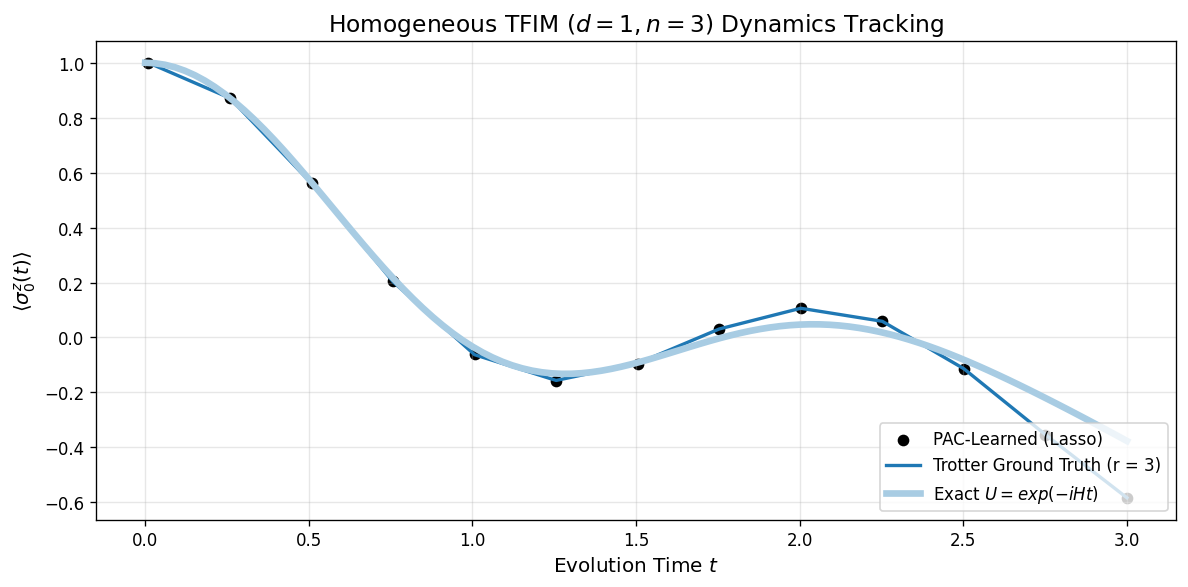

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(T_VALS, pac_pts_1, color='black', marker='o', label='PAC-Learned (Lasso)')
ax.plot(T_VALS, trotter_pts_1, color='#1f78b4', linewidth=2, label=f'Trotter Ground Truth (r = {R_STEPS_1})')
ax.plot(T_DENSE, exact_traj_1, color='#a8cce3', linewidth=4, label='Exact $U = exp(-iHt)$')

ax.set_xlabel(r'Evolution Time $t$')
ax.set_ylabel(r'$\langle\sigma_0^z(t)\rangle$')
ax.set_title(rf'Homogeneous TFIM ($d=1, n={NUM_QUBITS_1}$) Dynamics Tracking')
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

In [6]:
NUM_QUBITS_2 = 3
R_STEPS_2    = 10

# 1. Initialize Physics and Observable
model_2 = TFIM(num_qubits=NUM_QUBITS_2, edge_prob=0.5, alpha_range=(0.6, 1.4))
obs_2 = StaggeredMagnetization(num_qubits=model_2.num_qubits)
# 2. Fix the state configuration and ground truth
alpha_star_2 = np.array([1.0])
rng = np.random.default_rng(SEED)
X_train_2 = [model_2.sample_x(rng) for _ in range(30)]
test_state_2 = [(0, 1), (1, 2)]  # A held-out 3-qubit chain graph

print(f"Training set size: {len(X_train_2)} graphs")
print(f"Held-out Test State: {test_state_2}")

Training set size: 30 graphs
Held-out Test State: [(0, 1), (1, 2)]


In [7]:
# Compute dense exact trajectory via matrix exponentiation
O_mat_2 = obs_2.to_sparse_pauli_op().to_matrix()
exact_traj_2 = np.empty(len(T_DENSE))

for i, t in enumerate(T_DENSE):
    if t == 0.0:
        psi = np.zeros(2**NUM_QUBITS_1, dtype=complex); psi[0] = 1.0
    else:
        U = model_2.exact_unitary(test_state_2, alpha_star_2, float(t))
        psi = U[:, 0]
    exact_traj_2[i] = float(np.real(np.conj(psi) @ O_mat_2 @ psi))

In [8]:
# Compute PAC-Learned and Trotter dynamics across time
trotter_pts_2 = np.empty(len(T_VALS))
pac_pts_2     = np.empty(len(T_VALS))

for j, tau in enumerate(T_VALS):
    t_0 = time.time()
    exp = Experiment(
        model=model_2, observable=obs_2, method='hadamard_lasso',
        tau=float(tau), r_steps=R_STEPS_2,
        trotter_order=2,
        lasso_alpha=1e-5, seed=SEED
    )
    
    # Generate Training Data and Fit
    y_train = exp.compute_trotter_labels(X_train_2, alpha_star_2, float(tau), R_STEPS_2)
    B_train = exp._extract_features(X_train_2)
    exp.learner.fit(B_train, y_train)

    # Predict on Held-Out Test State
    B_test = exp._extract_features([test_state_2])
    pac_pts_2[j]     = float(exp.learner.predict(B_test)[0])
    trotter_pts_2[j] = float(exp.compute_trotter_labels([test_state_2], alpha_star_2, float(tau), R_STEPS_2)[0])

    # Calculate Exact value at this specific tau
    U = model_2.exact_unitary(test_state_2, alpha_star_2, float(tau))
    psi = U[:, 0]
    exact_val = float(np.real(np.conj(psi) @ O_mat_2 @ psi))
    
    print(f"t={tau:5.2f} | Exact: {exact_val:+.4f} | Trotter: {trotter_pts_2[j]:+.4f} | PAC: {pac_pts_2[j]:+.4f} | Time: {time.time() - t_0:.2f}s")

t= 0.01 | Exact: +0.3333 | Trotter: +0.3333 | PAC: +0.3332 | Time: 15.57s
t= 0.26 | Exact: +0.2878 | Trotter: +0.2879 | PAC: +0.2974 | Time: 13.36s
t= 0.51 | Exact: +0.1604 | Trotter: +0.1604 | PAC: +0.1647 | Time: 13.11s
t= 0.76 | Exact: -0.0047 | Trotter: -0.0050 | PAC: +0.0109 | Time: 13.30s
t= 1.01 | Exact: -0.1159 | Trotter: -0.1170 | PAC: -0.1052 | Time: 12.76s
t= 1.26 | Exact: -0.1258 | Trotter: -0.1271 | PAC: -0.1226 | Time: 13.50s
t= 1.51 | Exact: -0.0715 | Trotter: -0.0722 | PAC: -0.0760 | Time: 13.33s
t= 1.75 | Exact: -0.0106 | Trotter: -0.0106 | PAC: -0.0103 | Time: 13.26s
t= 2.00 | Exact: +0.0212 | Trotter: +0.0228 | PAC: +0.0181 | Time: 12.78s
t= 2.25 | Exact: +0.0048 | Trotter: +0.0100 | PAC: +0.0025 | Time: 12.57s
t= 2.50 | Exact: -0.0452 | Trotter: -0.0358 | PAC: -0.0203 | Time: 12.51s
t= 2.75 | Exact: -0.0868 | Trotter: -0.0699 | PAC: -0.0527 | Time: 12.88s
t= 3.00 | Exact: -0.1161 | Trotter: -0.0815 | PAC: -0.0777 | Time: 11.61s


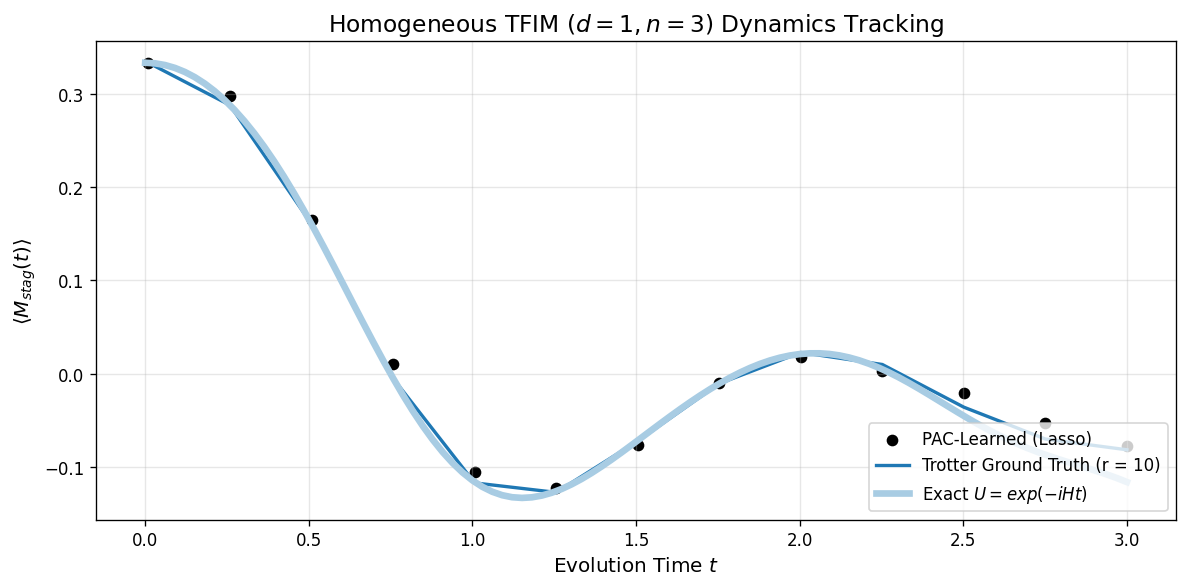

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(T_VALS, pac_pts_2, color='black', marker='o', label='PAC-Learned (Lasso)')
ax.plot(T_VALS, trotter_pts_2, color='#1f78b4', linewidth=2, label=f'Trotter Ground Truth (r = {R_STEPS_2})')
ax.plot(T_DENSE, exact_traj_2, color='#a8cce3', linewidth=4, label='Exact $U = exp(-iHt)$')


ax.set_xlabel(r'Evolution Time $t$')
ax.set_ylabel(r'$\langle M_{stag}(t) \rangle$')
ax.set_title(rf'Homogeneous TFIM ($d=1, n={NUM_QUBITS_2}$) Dynamics Tracking')
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

## Part 2: Inhomogeneous Regime ($d > 1$)
---
**Hamiltonian:** $H(x, \alpha) = \sum_{(i,j) \in x} Z_i Z_j + \sum_i \alpha_i X_i$ 

In the inhomogeneous regime, each qubit experiences an independent field strength $\alpha_i$, meaning $d = n_{qubits}$. The feature dimension explodes to $(4r + 1)^d$. Because this vastly exceeds the training set size (rank deficiency), we switch to Kernel Ridge Regression on the precomputed Gram Matrix (`meshgrid_kernel`).

In [10]:
NUM_QUBITS_2 = 3
R_STEPS_2    = 3

model_2 = InhomogeneousTFIM(num_qubits=NUM_QUBITS_2, edge_prob=0.5, alpha_range=(0.6, 1.4))
obs_2   = LocalMagnetization(num_qubits=NUM_QUBITS_2, site=0)

alpha_star_2 = np.array([0.9, 1.1, 0.7])
rng2 = np.random.default_rng(SEED + 1)
X_train_2 = [model_2.sample_x(rng2) for _ in range(30)]
test_state_2 = [(0, 2)]  # Held-out single-edge graph

print(f"Feature Space Dimension: {(4 * R_STEPS_2 + 1)**NUM_QUBITS_2}")
print(f"Training set size: {len(X_train_2)} graphs")

Feature Space Dimension: 2197
Training set size: 30 graphs


In [11]:
# Compute dense exact trajectory
O_mat_2 = obs_2.to_sparse_pauli_op().to_matrix()
exact_traj_2 = np.empty(len(T_DENSE))

for i, t in enumerate(T_DENSE):
    if t == 0.0:
        psi = np.zeros(2**NUM_QUBITS_2, dtype=complex); psi[0] = 1.0
    else:
        U = model_2.exact_unitary(test_state_2, alpha_star_2, float(t))
        psi = U[:, 0]
    exact_traj_2[i] = float(np.real(np.conj(psi) @ O_mat_2 @ psi))

In [12]:
# Compute PAC-Learned and Trotter dynamics across time
trotter_pts_2 = np.empty(len(T_VALS))
pac_pts_2     = np.empty(len(T_VALS))

for j, tau in enumerate(T_VALS):
    t_0 = time.time()
    exp = Experiment(
        model=model_2, observable=obs_2, method='meshgrid_kernel',
        tau=float(tau), r_steps=R_STEPS_2,
        trotter_order=2,
        kernel_alpha=1e-2, seed=SEED
    )
    
    y_train = exp.compute_trotter_labels(X_train_2, alpha_star_2, float(tau), R_STEPS_2)
    B_train = exp._extract_features(X_train_2)
    exp.learner.fit(B_train, y_train)

    # Safely wrap test_state_2 in a list for extraction
    B_test = exp._extract_features([test_state_2])
    
    pac_pts_2[j]     = float(exp.learner.predict(B_test)[0])
    trotter_pts_2[j] = float(exp.compute_trotter_labels([test_state_2], alpha_star_2, float(tau), R_STEPS_2)[0])

    U = model_2.exact_unitary(test_state_2, alpha_star_2, float(tau))
    psi = U[:, 0]
    exact_val = float(np.real(np.conj(psi) @ O_mat_2 @ psi))
    print(f"t={tau:5.2f} | Exact: {exact_val:+.4f} | Trotter: {trotter_pts_2[j]:+.4f} | PAC: {pac_pts_2[j]:+.4f} | Time: {time.time() - t_0:.2f}s")

t= 0.01 | Exact: +0.9998 | Trotter: +0.9998 | PAC: +0.9992 | Time: 1.80s
t= 0.26 | Exact: +0.8955 | Trotter: +0.8953 | PAC: +0.8936 | Time: 1.72s
t= 0.51 | Exact: +0.6421 | Trotter: +0.6388 | PAC: +0.6388 | Time: 1.79s
t= 0.76 | Exact: +0.3452 | Trotter: +0.3319 | PAC: +0.3347 | Time: 1.82s
t= 1.01 | Exact: +0.1191 | Trotter: +0.0902 | PAC: +0.0924 | Time: 1.76s
t= 1.26 | Exact: +0.0313 | Trotter: -0.0071 | PAC: -0.0069 | Time: 1.74s
t= 1.51 | Exact: +0.0707 | Trotter: +0.0514 | PAC: +0.0504 | Time: 1.72s
t= 1.75 | Exact: +0.1556 | Trotter: +0.2093 | PAC: +0.2098 | Time: 1.70s
t= 2.00 | Exact: +0.1778 | Trotter: +0.3723 | PAC: +0.3733 | Time: 1.82s
t= 2.25 | Exact: +0.0598 | Trotter: +0.4515 | PAC: +0.4517 | Time: 1.73s
t= 2.50 | Exact: -0.2032 | Trotter: +0.4001 | PAC: +0.3985 | Time: 1.75s
t= 2.75 | Exact: -0.5377 | Trotter: +0.2260 | PAC: +0.2218 | Time: 1.95s
t= 3.00 | Exact: -0.8264 | Trotter: -0.0205 | PAC: -0.0277 | Time: 1.88s


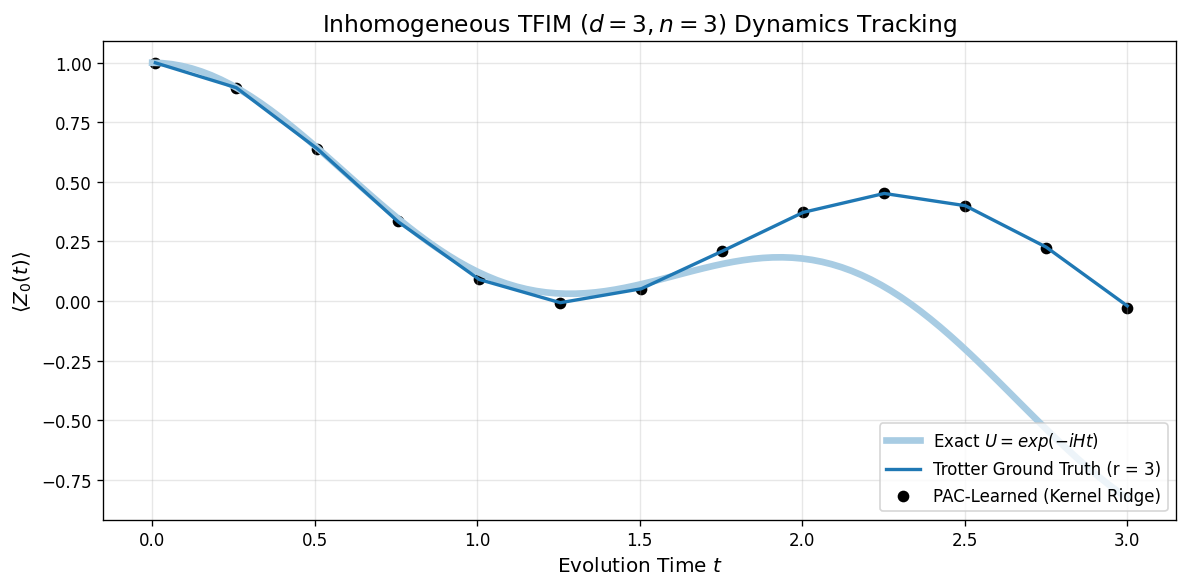

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(T_DENSE, exact_traj_2, color='#a8cce3', linewidth=4, label='Exact $U = exp(-iHt)$')
ax.plot(T_VALS, trotter_pts_2, color='#1f78b4', linewidth=2, label=f'Trotter Ground Truth (r = {R_STEPS_2})')
ax.scatter(T_VALS, pac_pts_2, color='black', marker='o', label='PAC-Learned (Kernel Ridge)')



ax.set_xlabel(r'Evolution Time $t$')
ax.set_ylabel(r'$\langle Z_0(t) \rangle$')
ax.set_title(rf'Inhomogeneous TFIM ($d=3, n={NUM_QUBITS_2}$) Dynamics Tracking')
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()